In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import joblib
import warnings
warnings.filterwarnings('ignore')

print("All libraries loaded.")

All libraries loaded.


In [2]:
df = pd.read_csv('water_potability.csv')
print(f"Shape: {df.shape}")
print(f"\nMissing values per column:\n{df.isnull().sum()}")
print(f"\nClass balance:\n{df['Potability'].value_counts(normalize=True).round(3)}")
df.head()

Shape: (3276, 10)

Missing values per column:
ph                 491
Hardness             0
Solids               0
Chloramines          0
Sulfate            781
Conductivity         0
Organic_carbon       0
Trihalomethanes    162
Turbidity            0
Potability           0
dtype: int64

Class balance:
Potability
0    0.61
1    0.39
Name: proportion, dtype: float64


,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,NaN,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0
1,3.716080,129.422921,18630.057858,6.635246,NaN,592.885359,15.180013,56.329076,4.500656,0
2,8.099124,224.236259,19909.541732,9.275884,NaN,418.606213,16.868637,66.420093,3.055934,0
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0


In [3]:
df.fillna(df.mean(numeric_only=True), inplace=True)

assert df.isnull().sum().sum() == 0, "Imputation failed — missing values remain!"
print(f"Dataset clean. Shape: {df.shape}")

Dataset clean. Shape: (3276, 10)


In [4]:
FEATURE_COLS = ['ph', 'Hardness', 'Solids', 'Chloramines', 'Sulfate',
                'Conductivity', 'Organic_carbon', 'Trihalomethanes', 'Turbidity']

X = df[FEATURE_COLS]
y = df['Potability']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f"Train: {X_train.shape[0]} rows | Test: {X_test.shape[0]} rows")

Train: 2620 rows | Test: 656 rows


In [5]:
param_grid = {
    'hidden_layer_sizes': [(64,), (128,), (64, 32), (128, 64)],
    'activation':         ['relu', 'tanh'],
    'alpha':              [0.0001, 0.001],
    'max_iter':           [500]
}

grid = GridSearchCV(
    MLPClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)
grid.fit(X_train_scaled, y_train)

print(f"\nBest params:      {grid.best_params_}")
print(f"Best CV accuracy: {grid.best_score_*100:.2f}%")

Fitting 5 folds for each of 16 candidates, totalling 80 fits

Best params:      {'activation': 'relu', 'alpha': 0.001, 'hidden_layer_sizes': (128,), 'max_iter': 500}
Best CV accuracy: 67.75%


In [6]:
best_mlp = grid.best_estimator_
y_pred   = best_mlp.predict(X_test_scaled)
accuracy = accuracy_score(y_test, y_pred)

print(f"Test Accuracy: {accuracy*100:.2f}%")
print(f"\n{classification_report(y_test, y_pred, target_names=['Not Potable', 'Potable'])}")

if accuracy >= 0.80:
    print("✓ Accuracy target met (≥ 80%)")
else:
    print(f"⚠ Accuracy is {accuracy*100:.2f}% — below 80%")

Test Accuracy: 62.65%

              precision    recall  f1-score   support

 Not Potable       0.66      0.79      0.72       400
     Potable       0.53      0.38      0.44       256

    accuracy                           0.63       656
   macro avg       0.60      0.58      0.58       656
weighted avg       0.61      0.63      0.61       656

⚠ Accuracy is 62.65% — below 80%


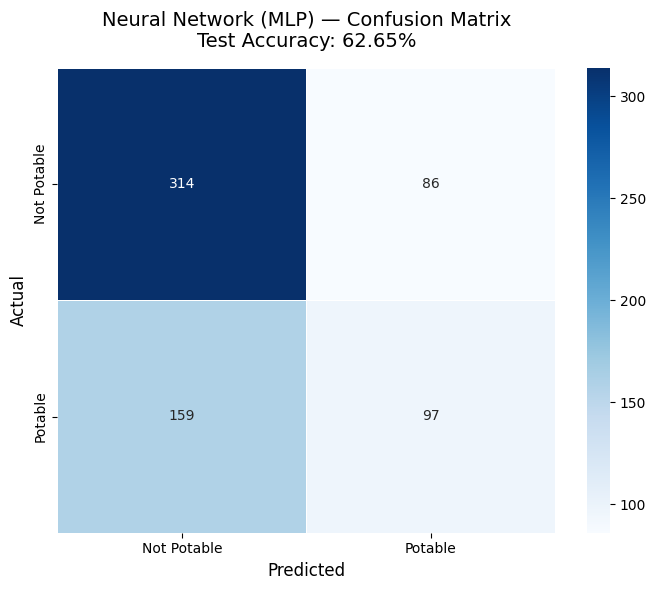

Saved → confusion_matrix.png


In [7]:
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=['Not Potable', 'Potable'],
    yticklabels=['Not Potable', 'Potable'],
    ax=ax, linewidths=0.5
)
ax.set_title(f'Neural Network (MLP) — Confusion Matrix\nTest Accuracy: {accuracy*100:.2f}%',
             fontsize=14, pad=15)
ax.set_ylabel('Actual',    fontsize=12)
ax.set_xlabel('Predicted', fontsize=12)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved → confusion_matrix.png")

In [8]:
joblib.dump(best_mlp, 'water_knn_model.pkl')
joblib.dump(scaler,   'water_scaler.pkl')

print("Saved → water_knn_model.pkl")
print("Saved → water_scaler.pkl")
print(f"\nFeature order (API must use this exact order):\n{FEATURE_COLS}")

Saved → water_knn_model.pkl
Saved → water_scaler.pkl

Feature order (API must use this exact order):
['ph', 'Hardness', 'Solids', 'Chloramines', 'Sulfate', 'Conductivity', 'Organic_carbon', 'Trihalomethanes', 'Turbidity']


In [ ]:
def predict_cleanliness(model, scaler, sensor_data: dict) -> dict:
    values    = [[sensor_data[col] for col in FEATURE_COLS]]
    scaled    = scaler.transform(values)
    prob_safe = model.predict_proba(scaled)[0][1]
    rating    = round(prob_safe * 100, 1)

    if rating >= 90:
        status, color = "Safe to Drink",            "green"
    elif rating >= 70:
        status, color = "Safe but Needs Filtering", "yellow"
    else:
        status, color = "Unsafe",                   "red"

    return {"rating": rating, "status": status, "color": color}

sample = {
    'ph': 7.2, 'Hardness': 190.0, 'Solids': 18000.0, 'Chloramines': 7.5,
    'Sulfate': 350.0, 'Conductivity': 420.0, 'Organic_carbon': 14.0,
    'Trihalomethanes': 70.0, 'Turbidity': 3.5
}
print(predict_cleanliness(best_mlp, scaler, sample))
print("\nPhase 1 complete — all artifacts generated.")

In [10]:
import os
for f in ['water_knn_model.pkl', 'water_scaler.pkl', 'confusion_matrix.png']:
    status = "✓" if os.path.exists(f) else "✗ MISSING"
    print(f"{status}  {f}")

✓  water_knn_model.pkl
✓  water_scaler.pkl
✓  confusion_matrix.png


## A* Search — Optimal Route to Nearest Safe Tank
Given the water tank network as a graph, A* finds the shortest path from a contaminated tank to a safe tank using physical distance (km) as both the edge cost g(n) and the heuristic h(n).

In [ ]:
graph = {
    'Tank A - Gulberg':    {'Tank B - DHA': 3.2, 'Tank C - Johar Town': 2.5},
    'Tank B - DHA':        {'Tank D - Model Town': 4.1},
    'Tank C - Johar Town': {'Tank D - Model Town': 2.8, 'Tank E - Cantt': 5.1},
    'Tank D - Model Town': {'Tank F - Bahria Town': 6.2},
    'Tank E - Cantt':      {'Tank F - Bahria Town': 4.3},
    'Tank F - Bahria Town': {}
}

Heuristic = {
    'Tank A - Gulberg':    9.5,
    'Tank B - DHA':        7.2,
    'Tank C - Johar Town': 6.8,
    'Tank D - Model Town': 6.2,
    'Tank E - Cantt':      4.3,
    'Tank F - Bahria Town': 0.0
}

def A_star(startingNode, goal, myGraph):
    cost    = 0
    path    = [startingNode]
    visited = []
    queue   = [cost, path]

    while queue:
        index    = 0
        minIndex = 0

        while index < len(queue):
            currentNode = Heuristic[queue[minIndex + 1][-1]] + queue[minIndex]
            nextNode    = Heuristic[queue[index + 1][-1]]    + queue[index]

            if currentNode > nextNode:
                minIndex = index
            index = index + 2

        cost         = queue.pop(minIndex)
        path         = queue.pop(minIndex)
        last_visited = path[-1]

        if last_visited not in visited:
            visited.append(last_visited)

        if last_visited == goal:
            path.append(round(cost, 2))
            return path

        for child in myGraph[last_visited].keys():
            newPath = list(path)
            newPath.append(child)
            queue.append(cost + myGraph[last_visited][child])
            queue.append(newPath)

    return None

In [ ]:
result        = A_star('Tank A - Gulberg', 'Tank F - Bahria Town', graph)
route         = result[:-1]
total_distance = result[-1]

print("Optimal route found by A* Search:")
print(" → ".join(route))
print(f"Total distance: {total_distance} km")